In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ethicaldilemma.csv to ethicaldilemma.csv


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# **Run all of this before k-means part**

In [ ]:
df = pd.read_csv('ethicaldilemma.csv')

In [ ]:
# Define target and features
target = "Saved"
features = ["PedPed", "Barrier", "CrossingSignal", "ScenarioTypeStrict", "NumberOfCharacters", "Template", "DescriptionShown", "LeftHand",
            "Man", "Woman", "Pregnant", "Stroller", "OldMan", "OldWoman", "Boy", "Girl", "Homeless", "LargeWoman", "LargeMan", "Criminal",
            "MaleExecutive", "FemaleExecutive", "FemaleAthlete", "MaleAthlete", "FemaleDoctor", "MaleDoctor", "Dog", "Cat"]

# Define X and y
X = df[features]
y = df[target].astype(int)

# Categorical columns
cat_cols = ["PedPed", "Barrier", "CrossingSignal", "ScenarioTypeStrict", "Template", "DescriptionShown", "LeftHand"]

# Convert CatBoost categorical features to strings and fill NA
X[cat_cols] = X[cat_cols].fillna("NA").astype(str)

# Numeric columns
num_cols = [col for col in features if col not in cat_cols]

# Preprocessor for tree/XGB/logreg models
preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore", drop='first'), cat_cols),
                                               ("num", StandardScaler(), num_cols)])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Models
models = {"Random Forest": RandomForestClassifier(random_state=42),
          "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
          "Gradient Boosting": GradientBoostingClassifier(random_state=42),
          "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)}

results = []

# Train tree-based, logreg, and XGB (with preprocessing)
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({"Model": name,
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "ROC-AUC": roc_auc_score(y_test, y_prob)})

# Train CatBoost separately (NO preprocessing)
cat_model = CatBoostClassifier(iterations=1000,
                               loss_function='Logloss',
                               eval_metric='AUC',
                               random_state=42,
                               verbose=False)
cat_model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_test, y_test), use_best_model=True)

# Predictions for CatBoost
y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:, 1]

# Add CatBoost to results
results.append({"Model": "CatBoost",
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "ROC-AUC": roc_auc_score(y_test, y_prob)})

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

/tmp/ipython-input-1786939227.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_cols] = X[cat_cols].fillna("NA").astype(str)


# **K-Means**

In [ ]:
# Preprocess data
X_full = preprocessor.transform(X)

kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X_full)

# Add cluster labels to original dataframe
df["Cluster"] = clusters

cluster_summary = df.groupby('Cluster')['Saved'].agg(['mean', 'count']).rename(
    columns={'mean': 'Saved_Rate', 'count': 'Num_Cases'})

cluster_summary

,Saved_Rate,Num_Cases
Cluster,,
0,0.634066,15470
1,0.325224,7604
2,0.666212,10998
3,0.473163,7974
4,0.586497,7613
5,0.481418,35921
6,0.224110,7358
7,0.537100,7062


In [ ]:
import pandas as pd

data = {
    "Cluster":   [0, 1, 2, 3, 4, 5, 6, 7],
    "Saved_Rate": [0.634066, 0.325224, 0.666212, 0.473163,
                   0.586497, 0.481418, 0.224110, 0.537100],
    "Num_Cases":  [15470, 7604, 10998, 7974,
                   7613, 35921, 7358, 7062]
}

cluster_summary = pd.DataFrame(data).set_index("Cluster")
cluster_summary

,Saved_Rate,Num_Cases
Cluster,,
0,0.634066,15470
1,0.325224,7604
2,0.666212,10998
3,0.473163,7974
4,0.586497,7613
5,0.481418,35921
6,0.224110,7358
7,0.537100,7062


Clusters with Saved_Rate > 0.70 = moral preference group

Clusters with Saved_Rate < 0.30 = morally deprioritized group

# **Seeing what is in each cluster**

In [ ]:
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

cluster_profile = df.groupby('Cluster')[features].mean()

cluster_key_traits = {}

for cluster in df['Cluster'].unique():
    row = cluster_profile.loc[cluster]
    top_features = row.sort_values(ascending=False).head(8)
    cluster_key_traits[cluster] = top_features
for cluster, traits in cluster_key_traits.items():
    print(f"\n=== Cluster {cluster} ===")
    print(traits)


=== Cluster 4 ===
NumberOfCharacters    3.809274
MaleAthlete           1.385131
FemaleAthlete         1.362538
CrossingSignal        0.589387
LeftHand              0.497049
PedPed                0.470774
Man                   0.333114
Woman                 0.318009
Name: 4, dtype: float64

=== Cluster 3 ===
NumberOfCharacters    3.996363
LargeMan              1.058440
LargeWoman            0.995736
Man                   0.674066
Woman                 0.655882
CrossingSignal        0.607223
LeftHand              0.504248
PedPed                0.462629
Name: 3, dtype: float64

=== Cluster 5 ===
NumberOfCharacters    1.614292
CrossingSignal        0.604382
LeftHand              0.502430
PedPed                0.447148
Barrier               0.275911
Man                   0.271318
Woman                 0.268200
DescriptionShown      0.262727
Name: 5, dtype: float64

=== Cluster 6 ===
NumberOfCharacters    3.547703
Dog                   1.724110
Cat                   1.710247
CrossingSignal 

In [ ]:
from sklearn.metrics import silhouette_score

Ks = range(3, 10)
inertias = []
sil_scores = []

for k in Ks:
    kmeans_k = KMeans(n_clusters=k, random_state=42)
    labels_k = kmeans_k.fit_predict(X_full)
    inertias.append(kmeans_k.inertia_)
    sil_scores.append(silhouette_score(X_full, labels_k, sample_size=10000, random_state=42))

for k, iner, sil in zip(Ks, inertias, sil_scores):
    print(f"k={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

k=3: inertia=2119312.68, silhouette=0.074
k=4: inertia=2024326.49, silhouette=0.073
k=5: inertia=1944145.23, silhouette=0.092
k=6: inertia=1876030.17, silhouette=0.100
k=7: inertia=1806861.48, silhouette=0.103
k=8: inertia=1674313.51, silhouette=0.121
k=9: inertia=1601961.07, silhouette=0.127


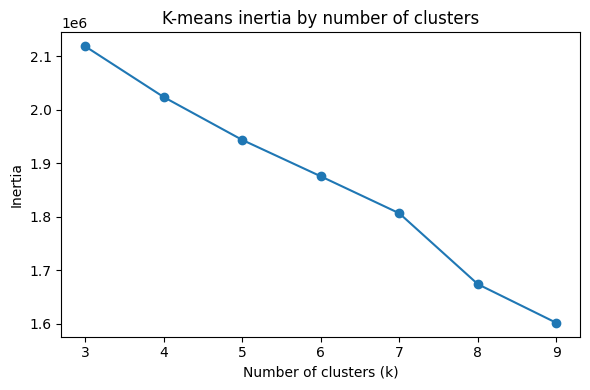

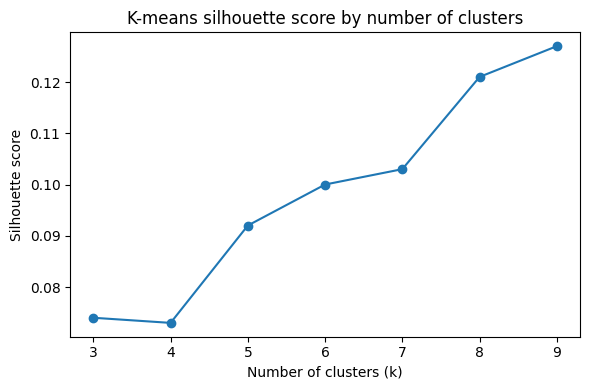

In [ ]:
import matplotlib.pyplot as plt

# 데이터
Ks = [3, 4, 5, 6, 7, 8, 9]
inertias = [2119312.68, 2024326.49, 1944145.23, 1876030.17,
            1806861.48, 1674313.51, 1601961.07]
silhouettes = [0.074, 0.073, 0.092, 0.100, 0.103, 0.121, 0.127]

# 1) Inertia vs k
plt.figure(figsize=(6, 4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means inertia by number of clusters")
plt.xticks(Ks)
plt.tight_layout()
plt.show()

# 2) Silhouette vs k
plt.figure(figsize=(6, 4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-means silhouette score by number of clusters")
plt.xticks(Ks)
plt.tight_layout()
plt.show()

   Cluster  Saved_Rate  Num_Cases
2        2    0.666212      10998
0        0    0.634066      15470
4        4    0.586497       7613
7        7    0.537100       7062
5        5    0.481418      35921
3        3    0.473163       7974
1        1    0.325224       7604
6        6    0.224110       7358


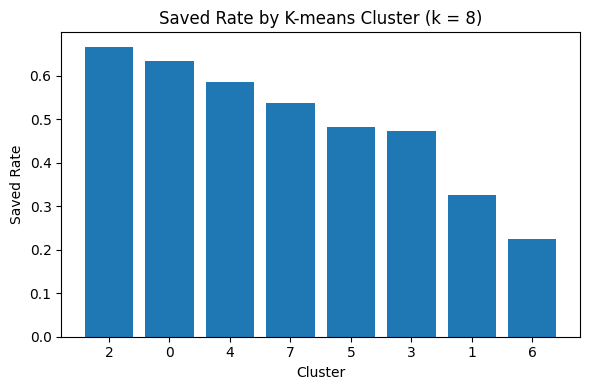

In [ ]:
import matplotlib.pyplot as plt

# 1) Summarize Saved_Rate and number of cases by cluster
cluster_summary = (
    df.groupby("Cluster")["Saved"]
      .agg(Saved_Rate="mean", Num_Cases="size")
      .reset_index()
)

# Sort clusters by Saved_Rate (descending) for nicer visualization
cluster_summary = cluster_summary.sort_values("Saved_Rate", ascending=False)

print(cluster_summary)

# 2) Plot bar chart of Saved_Rate by cluster
plt.figure(figsize=(6, 4))
plt.bar(cluster_summary["Cluster"].astype(str), cluster_summary["Saved_Rate"])
plt.xlabel("Cluster")
plt.ylabel("Saved Rate")
plt.title("Saved Rate by K-means Cluster (k = 8)")
plt.tight_layout()
plt.show()